In [1]:
# STEP 1
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os


# CONFIGURATION

TEST_DATA_PATH = r"E:\IDS IPS Project\data\test_processed.csv"
MODEL_DIR = r"E:\IDS IPS Project\models"
RESULTS_PATH = r"E:\IDS IPS Project\results\model_comparison.csv"

print(" Paths configured successfully.")


 Paths configured successfully.


In [2]:
# STEP 2
# Load your preprocessed test dataset
df = pd.read_csv(TEST_DATA_PATH)

X_test = df.drop(columns=["Label"])
y_test = df["Label"]

print(f"Test data loaded: {df.shape}")
print(f" Classes in test data:\n{y_test.value_counts()}")


Test data loaded: (6327, 16)
 Classes in test data:
Label
DoS GoldenEye    1000
DDoS             1000
BENIGN           1000
DoS Hulk          999
DoS slowloris     962
FTP-Patator       722
SSH-Patator       644
Name: count, dtype: int64


In [8]:
#STEP 3
from sklearn.preprocessing import LabelEncoder

# Encode target labels (same as in training)
le = LabelEncoder()
y_encoded = le.fit_transform(y_test)

def evaluate_saved_model(model_path, X, y_true, label_encoder):
    bundle = joblib.load(model_path)
    model = bundle["model"]
    le_model = bundle["label_encoder"]

    y_pred = model.predict(X)
    # Decode predictions
    y_pred_labels = le_model.inverse_transform(y_pred)
    y_true_labels = y_true

    # Encode decoded predictions again for metrics
    y_pred_encoded = label_encoder.transform(y_pred_labels)
    y_true_encoded = label_encoder.transform(y_true_labels)

    acc = accuracy_score(y_true_encoded, y_pred_encoded)
    pre = precision_score(y_true_encoded, y_pred_encoded, average="weighted", zero_division=0)
    rec = recall_score(y_true_encoded, y_pred_encoded, average="weighted", zero_division=0)
    f1 = f1_score(y_true_encoded, y_pred_encoded, average="weighted", zero_division=0)

    print(f" {os.path.basename(model_path)} evaluation complete.")
    return {
        "Model": os.path.basename(model_path).replace("_model.pkl", "").replace("_", " ").title(),
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1-Score": f1
    }


In [10]:

#  STEP 4: Match feature names before evaluating


# Load top features (same ones used in selected_features_dataset.csv)
selected_data_path = r"E:\IDS IPS Project\data\selected_features_dataset.csv"
selected_df = pd.read_csv(selected_data_path)
top_features = [col for col in selected_df.columns if col != "Label"]

print(f"Using {len(top_features)} features from training dataset:\n{top_features}\n")

# Evaluate all models
model_files = [
    "random_forest_model.pkl",
    "xgboost_model.pkl",
    "svm_model.pkl",
    "logistic_regression_model.pkl"
]

results = []

for mf in model_files:
    path = os.path.join(MODEL_DIR, mf)

    # Align test dataset with same features
    X_test_aligned = X_test[top_features]

    # Run evaluation safely
    try:
        res = evaluate_saved_model(path, X_test_aligned, y_test, le)
        results.append(res)
    except Exception as e:
        print(f" Error evaluating {mf}: {e}")


Using 15 features from training dataset:
['Destination Port', 'Fwd Packet Length Max', 'Fwd IAT Std', 'Bwd Packet Length Max', 'Init_Win_bytes_forward', 'Fwd IAT Mean', 'min_seg_size_forward', 'Flow IAT Mean', 'Bwd Packets/s', 'Total Fwd Packets', 'Flow Packets/s', 'act_data_pkt_fwd', 'Total Length of Fwd Packets', 'Init_Win_bytes_backward', 'Fwd Packet Length Mean']

 random_forest_model.pkl evaluation complete.
 xgboost_model.pkl evaluation complete.
 svm_model.pkl evaluation complete.
 logistic_regression_model.pkl evaluation complete.


In [11]:
# STEP 5
# Create DataFrame for comparison
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(" Model Comparison Results:")
display(results_df)

# Save to /results folder
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
results_df.to_csv(RESULTS_PATH, index=False)
print(f" Results saved to: {RESULTS_PATH}")


 Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.998894,0.998894,0.998894,0.998894
1,Xgboost,0.998578,0.998579,0.998578,0.998578
2,Svm,0.973289,0.973917,0.973289,0.973337
3,Logistic Regression,0.916864,0.921431,0.916864,0.917499


 Results saved to: E:\IDS IPS Project\results\model_comparison.csv


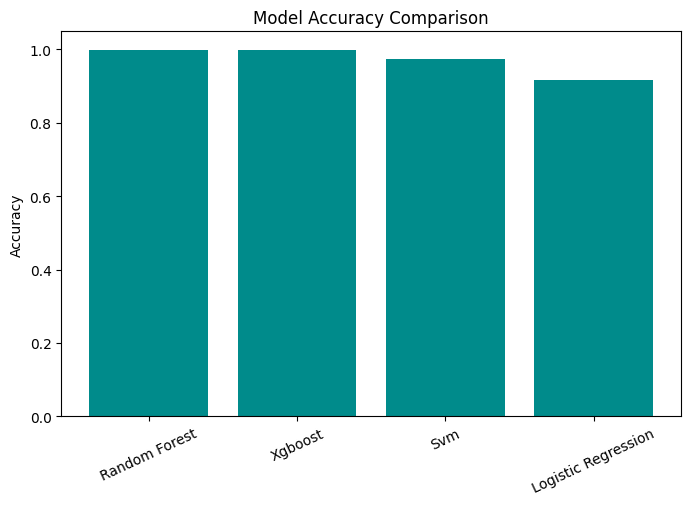

In [12]:
# STEP 6
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"], color='darkcyan')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.show()
